In [2]:
#imort initial libraries
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

Part 1: Dataset Selection and Identify Data Types
Choose ONE dataset:
• Titanic dataset (from Seaborn)
• Iris dataset (from Seaborn)
You must clearly state which dataset you selected.
Selecting Iris Dataset
Tasks Identify Data Types
• Load the dataset
• Identify categorical, numerical, and boolean variables
Questions:
1. How many categorical variables are in the dataset?
### There is one categorical value, which is species.
2. Give two examples of numerical variables and explain why they are numerical.
### Two numerical values are sepal_length and petal_width. Because they are data type Float, they are measureable, and arithemetic operations like mean, median can be applied on them.

In [6]:
iris_csv = '/Users/rukku/Documents/Sheridan/Python/PythonProject/iris.csv'
iris = pd.read_csv(iris_csv)
print(iris.head(8))
print(iris.info())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
mem

Part 2: Summary Statistics
Tasks:
• Select TWO numerical variables
• Compute mean and median
• Compute Standard deviation
• Compute mean square deviation
• Compute the 25th, 50th, and 75th percentiles
• Compute the range and interquartile range (IQR)

In [28]:
#median
print("Median:", iris[['sepal_length','petal_length']].median())
#mean
print("Mean:",iris[['sepal_length','petal_length']].mean())
#Standard deviation
print("Std_Dev:",iris[['sepal_length','petal_length']].std())
#Mean Square Deviation
print("MAD:",robust.scale.mad(iris[['sepal_length','petal_length']]))
print(abs(iris[['sepal_length','petal_length']] - iris[['sepal_length','petal_length']].median()).median() / 0.6744897501960817)
#percentiles
# Percentiles
Q1 = iris[['sepal_length','petal_length']].quantile(0.25)
Q3 = iris[['sepal_length','petal_length']].quantile(0.75)

print("Q1:")
print(Q1)

print("\nQ3:")
print(Q3)

# IQR
IQR = Q3 - Q1

print("\nIQR:")
print(IQR)

Median: sepal_length    5.80
petal_length    4.35
dtype: float64
Mean: sepal_length    5.843333
petal_length    3.758000
dtype: float64
Std_Dev: sepal_length    0.828066
petal_length    1.765298
dtype: float64
MAD: [1.03782155 1.85325277]
sepal_length    1.037822
petal_length    1.853253
dtype: float64
Q1:
sepal_length    5.1
petal_length    1.6
Name: 0.25, dtype: float64

Q3:
sepal_length    6.4
petal_length    5.1
Name: 0.75, dtype: float64

IQR:
sepal_length    1.3
petal_length    3.5
dtype: float64


Questions:
1. What does the median tell you about the typical value?
### The median represents the middle value of the dataset after sorting. It shows the typical central value and is less affected by outliers
2. How does the IQR help describe the spread of the data?
### The interquartile range (IQR) measures the spread of the middle 50% of the data. It helps identify variability and possible outliers.


Part 3: Frequency Counts for Categorical Variables
Tasks:
• Select TWO categorical variables
• Compute value counts
• Compute percentages for each category

In [10]:
# Frequency counts
print(iris['species'].value_counts())

# Percentages
print(iris['species'].value_counts(normalize=True) * 100)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


Questions:
1. Which category has the highest frequency?
### All three species setosa,versicolor and virginica  have equal frequency
2. Are the categories evenly distributed? Explain briefly.
### Yes. Each species appears 50 times, so the categories are evenly distributed

Part 4: Histograms and Boxplots
Tasks:
• Plot a histogram for ONE numerical variable
• Plot a boxplot for a DIFFERENT numerical variable

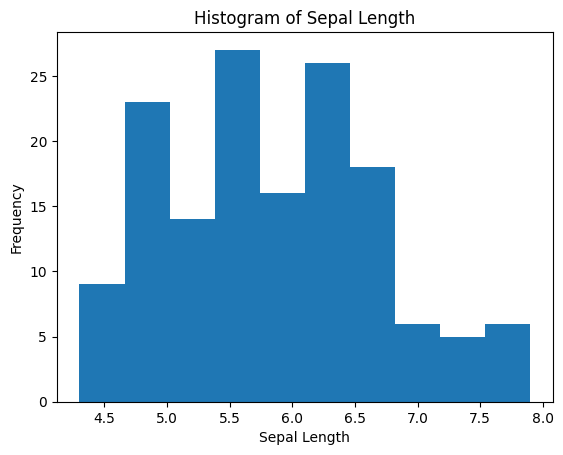

In [11]:
import matplotlib.pyplot as plt

plt.hist(iris['sepal_length'], bins=10)

plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')

plt.show()

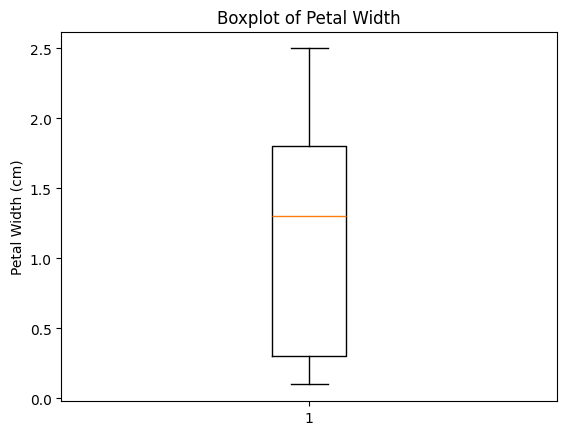

In [29]:
plt.boxplot(iris['petal_width'])

plt.title('Boxplot of Petal Width')
plt.ylabel('Petal Width (cm)')

plt.show()

Questions:
1. Describe the shape of each distribution (symmetric, skewed).
### Histogram (Sepal Length): The histogram distribution is approximately symmetric with a slight right skew. Most values are concentrated between 5 and 7 cm, with a small tail extending toward higher sepal lengths.

### Boxplot (Petal Width):The distribution appears fairly balanced with moderate spread and no strong evidence of skewness.

2. Are there any outliers? How can you tell?
### No clear outliers are visible. Boxplots indicate outliers as individual points beyond the whiskers, and no such points appear in this plot

Part 5: Bar Charts for Categorical Variables
Tasks:
• Create a bar chart for ONE categorical variable
• If possible, use color (hue) to compare with another grouping variable

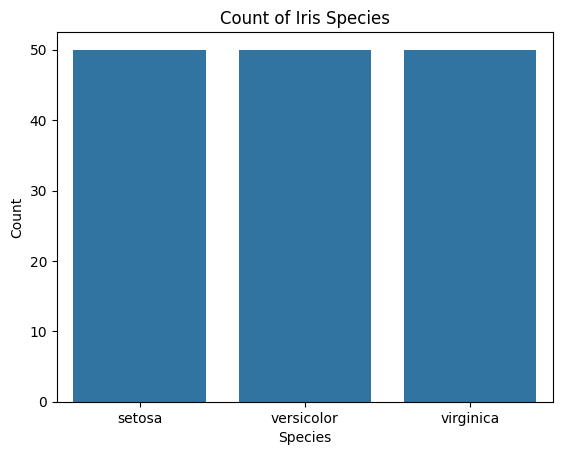

In [30]:
import seaborn as sns
sns.countplot(x='species', data=iris)

plt.title('Count of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

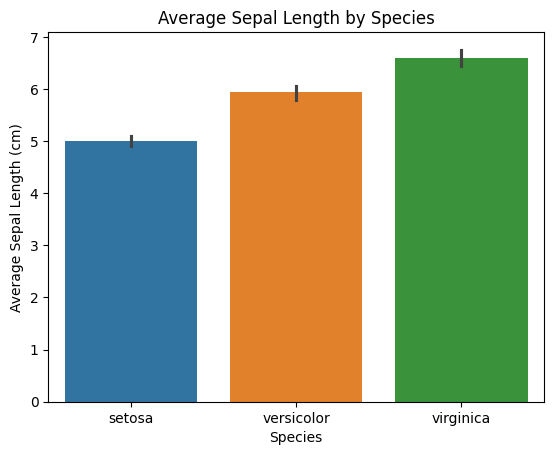

In [31]:
#with hue
sns.barplot(
    x='species',
    y='sepal_length',
    hue='species',
    data=iris
)

plt.title('Average Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Average Sepal Length (cm)')
plt.show()

Questions:
1. Which category has the highest count?
### No category has the highest count; all three species have the same count (50 observations each).
2. What differences do you observe across groups?
### Virginica has the highest average sepal length, Versicolor is in the middle, and Setosa has the lowest average sepal length.

Part 6: Percentiles and Comparisons
Tasks:
• Select ONE numerical variable
• Compute the 10th, 25th, 50th, 75th, and 90th percentiles
• Identify observations in the top 10%

In [17]:
# Percentiles
print(iris['petal_length'].quantile([0.10,0.25,0.50,0.75,0.90]))

0.10    1.40
0.25    1.60
0.50    4.35
0.75    5.10
0.90    5.80
Name: petal_length, dtype: float64


In [18]:
#top 10
p90 = iris['petal_length'].quantile(0.90)

top10 = iris[iris['petal_length'] >= p90]

print(top10)

     sepal_length  sepal_width  petal_length  petal_width    species
100           6.3          3.3           6.0          2.5  virginica
102           7.1          3.0           5.9          2.1  virginica
104           6.5          3.0           5.8          2.2  virginica
105           7.6          3.0           6.6          2.1  virginica
107           7.3          2.9           6.3          1.8  virginica
108           6.7          2.5           5.8          1.8  virginica
109           7.2          3.6           6.1          2.5  virginica
117           7.7          3.8           6.7          2.2  virginica
118           7.7          2.6           6.9          2.3  virginica
122           7.7          2.8           6.7          2.0  virginica
125           7.2          3.2           6.0          1.8  virginica
129           7.2          3.0           5.8          1.6  virginica
130           7.4          2.8           6.1          1.9  virginica
131           7.9          3.8    

Questions:
1. What does the 10th percentile tell you?
### The 10th percentile is the petal length value below which 10% of the flowers fall. It helps identify the lower end of the distribution and shows what constitutes a relatively small petal length in the dataset
2. How would you describe the observations in the top 10%?
### The top 10% consists of flowers with the largest petal lengths in the dataset. These observations are all Virginica flowers, indicating that Virginica tends to have substantially longer petals than the other Iris species.